# **🌟 CNN + GAN Fusion: Image Repair & Enhancement System**

## **💡 Overview**
This notebook demonstrates a **practical workflow to enhance low-resolution images using GANs**.  
We take AI-generated cat images and use a **Super-Resolution GAN (SRGAN)** to restore them to high quality.  

The workflow includes:  
- Visualizing **low-resolution** and **high-resolution** images 🖼️  
- Building a **GAN for image super-resolution** 🚀  
- Evaluating results using **PSNR, SSIM, and perceptual loss** 🧠✨  
- Side-by-side comparisons to showcase **visual improvements** 🐱🌟  

---

## **📁 Dataset**
We use a custom AI-generated cat image dataset containing:  
1. **High-resolution images (128×128 px)** 🐱  
2. **Low-resolution images (64×64 px)** 📉  

This allows us to simulate **realistic image enhancement scenarios**.

---

## **🎯 Objective**
- Train a **Generator** to convert low-res images → high-res images  
- Train a **Discriminator** to evaluate realism  
- Measure GAN performance using:  
  - **PSNR (Peak Signal-to-Noise Ratio)**  
  - **SSIM (Structural Similarity Index)**  
  - **VGG19-based Perceptual Loss**  

The goal is to **demonstrate how GANs can "repair" and enhance images** in a visually appealing way.

---

## **🚀 Why This Notebook is Unique**
- Combines **CNN + GAN fusion** for practical image enhancement  
- Includes **quantitative metrics + visual comparisons**  
- Fully **Kaggle-ready**: easy to understand, interactive, and visually engaging  
- Ideal for users exploring **AI image restoration, super-resolution, or GANs**

---

## **📊 Expected Outcome**
- High-quality GAN-enhanced images that are **closer to the original high-res images**  
- **PSNR & SSIM metrics** indicating improvement  
- **Perceptual feature-level similarity** measured via VGG19  
- **Visual side-by-side comparisons** showing the impact of GAN enhancement

# **🚀 1. IMPORTS & SETUP**

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.optimizers import Adam

# **📂 2. LOAD DATASET PATHS**

In [5]:
HIGH_RES_PATH = "/kaggle/input/ai-generated-cats-high-res-images-and-prompts/AI Generated Cat Images for Classification/AI Images"
LOW_RES_PATH  = "/kaggle/input/ai-generated-cats-high-res-images-and-prompts/AI Generated Cat Images for Classification/Resized"

high_images = sorted(glob(HIGH_RES_PATH + "/*.jpg"))
low_images  = sorted(glob(LOW_RES_PATH + "/*.jpg"))

print("High-Res Images:", len(high_images))
print("Low-Res Images:", len(low_images))

High-Res Images: 1000
Low-Res Images: 1000


# **👀 3. VISUALIZATION (Sample Images)**

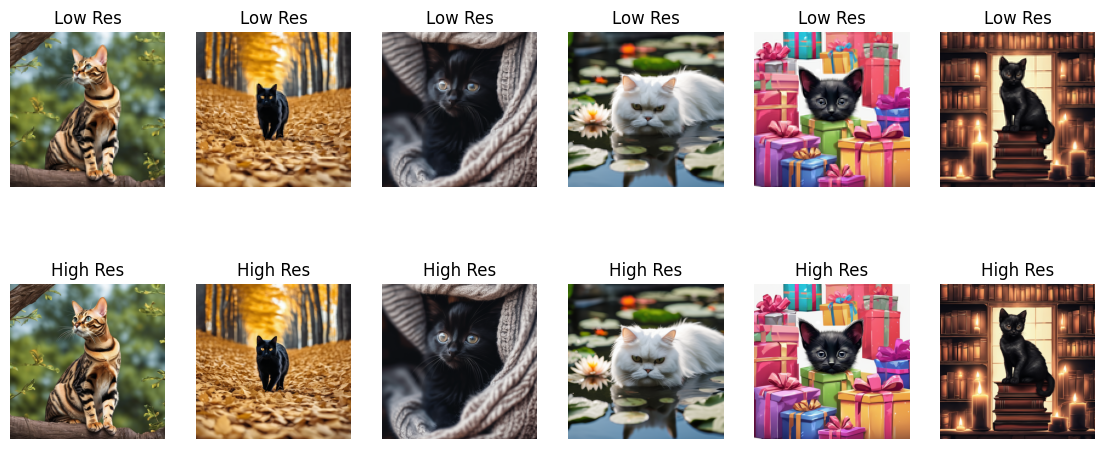

In [6]:
def load_image(path, size=None):
    img = Image.open(path).convert("RGB")
    if size:
        img = img.resize(size)
    return np.array(img)

def show_samples(high_paths, low_paths, n=6):
    plt.figure(figsize=(14, 6))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(load_image(low_paths[i]))
        plt.title("Low Res")
        plt.axis("off")

        plt.subplot(2, n, n+i+1)
        plt.imshow(load_image(high_paths[i]))
        plt.title("High Res")
        plt.axis("off")
    plt.show()

show_samples(high_images, low_images)

# **🧹 4. PREPARE TRAINING DATA**

In [7]:
IMG_LOW = (64, 64)
IMG_HIGH = (128, 128)

X_low  = np.array([load_image(img, IMG_LOW) for img in low_images]) / 255.0
X_high = np.array([load_image(img, IMG_HIGH) for img in high_images]) / 255.0

print("Low shape:", X_low.shape)
print("High shape:", X_high.shape)

Low shape: (1000, 64, 64, 3)
High shape: (1000, 128, 128, 3)


# **🎯 5. DEFINE THE SRGAN**

## **5.1 Generator**

In [11]:
def build_generator():
    inp = layers.Input(shape=(64,64,3))
    x = layers.UpSampling2D(size=2)(inp)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    out = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)
    return models.Model(inp, out)

generator = build_generator()
generator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,451 (158.01 KB)

 Trainable params: 40,451 (158.01 KB)

 Non-trainable params: 0 (0.00 B)

## **5.2 Discriminator**

In [12]:
def build_discriminator():
    inp = layers.Input(shape=(128,128,3))
    x = layers.Conv2D(64, 3, strides=2, padding='same')(inp)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, x)

discriminator = build_discriminator()
discriminator.compile(optimizer=Adam(0.0002), loss='binary_crossentropy', metrics=['accuracy'])

## **5.3 Combined SRGAN**

In [13]:
discriminator.trainable = False
inp_lr = layers.Input(shape=(64,64,3))
fake_hr = generator(inp_lr)
validity = discriminator(fake_hr)

srgan = models.Model(inp_lr, [fake_hr, validity])
srgan.compile(
    loss=['mse', 'binary_crossentropy'],
    loss_weights=[1, 1e-3],
    optimizer=Adam(0.0002)
)

# **6. 🚀 TRAIN THE SRGAN**

In [14]:
epochs = 1000
batch_size = 16

for epoch in range(epochs):
    idx = np.random.randint(0, X_low.shape[0], batch_size)
    imgs_lr = X_low[idx]
    imgs_hr = X_high[idx]

    # Generate fake HR images
    fake_hr = generator.predict(imgs_lr)

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(imgs_hr, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_hr, np.zeros((batch_size,1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train generator
    g_loss = srgan.train_on_batch(imgs_lr, [imgs_hr, np.ones((batch_size,1))])

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss} | G Loss: {g_loss}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")
2026-02-02 14:39:49.547436: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 14:39:49.814967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 14:39:50.842541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 14:39:51.143985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.

Epoch 0 | D Loss: [0.72699654 0.25      ] | G Loss: [array(0.06291308, dtype=float32), array(0.06215887, dtype=float32), array(0.7542156, dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━

# **7. 🖼️ APPLY GAN AND VISUALIZE**

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


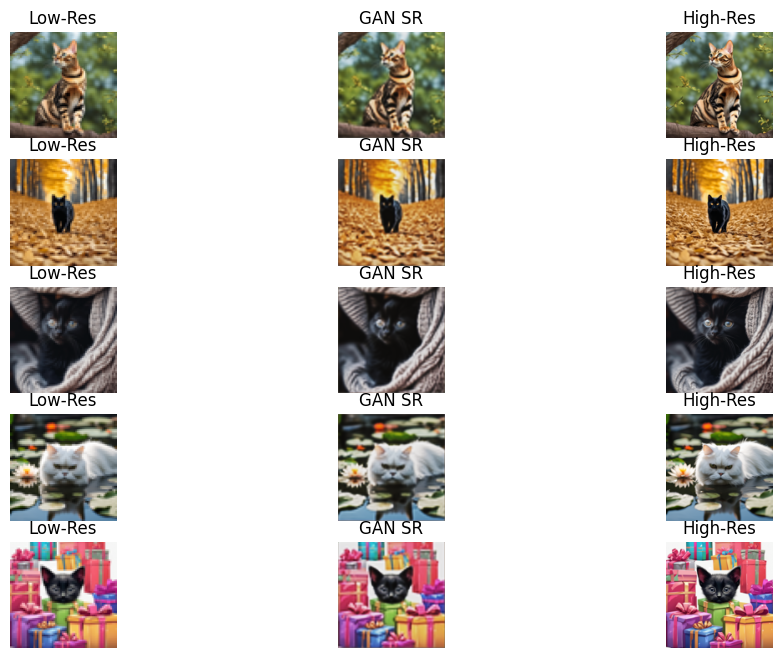

In [15]:
X_sr = generator.predict(X_low)

n = 5
plt.figure(figsize=(12,8))
for i in range(n):
    plt.subplot(n, 3, 3*i+1)
    plt.imshow(X_low[i])
    plt.title("Low-Res")
    plt.axis("off")

    plt.subplot(n, 3, 3*i+2)
    plt.imshow(X_sr[i])
    plt.title("GAN SR")
    plt.axis("off")

    plt.subplot(n, 3, 3*i+3)
    plt.imshow(X_high[i])
    plt.title("High-Res")
    plt.axis("off")
plt.show()

# **🧪 8. EVALUATE IMAGE QUALITY: PSNR & SSIM**

In [18]:
psnr_scores = []
ssim_scores = []

for i in range(len(X_sr)):
    psnr_scores.append(psnr(X_high[i], X_sr[i], data_range=1.0))
    # Updated for new skimage version: use channel_axis instead of multichannel
    ssim_scores.append(ssim(X_high[i], X_sr[i], data_range=1.0, channel_axis=-1))

print("Average PSNR:", np.mean(psnr_scores))
print("Average SSIM:", np.mean(ssim_scores))

Average PSNR: 27.032115928853425
Average SSIM: 0.9184899109105739


# **9. 🧠 VGG19-BASED PERCEPTUAL LOSS**

In [17]:
vgg = VGG19(include_top=False, input_shape=(128,128,3))
vgg.trainable = False

def perceptual_loss(y_true, y_pred):
    y_true_vgg = vgg(y_true)
    y_pred_vgg = vgg(y_pred)
    return tf.reduce_mean(tf.square(y_true_vgg - y_pred_vgg))

# Example
loss_val = perceptual_loss(tf.convert_to_tensor(X_high[:5]), tf.convert_to_tensor(X_sr[:5]))
print("Sample Perceptual Loss:", loss_val.numpy())

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Perceptual Loss: 0.018741796


# **ThankYou**